In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# Capstone Final Project: Developmental Screening Prediction


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

os.makedirs("images", exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Business Understanding

Early childhood developmental screening is a critical preventive health service that helps identify developmental delays, behavioral concerns, and disabilities during the first years of life. Early detection enables timely intervention, which can significantly improve long-term health, educational, and social outcomes for children.

Despite national recommendations that children receive routine developmental screening during early well-child visits, many children do not receive these assessments. Missed screenings can delay diagnosis and access to early intervention services, particularly among vulnerable populations.

### Problem Statement

Public health agencies, healthcare providers, and policymakers need a data-driven way to identify which children are most at risk of not receiving developmental screening. Understanding these risk factors can help target outreach, allocate resources efficiently, and reduce disparities in early childhood care.

### Project Objective

The objective of this project is to develop predictive models that estimate whether a child aged 0–3 has received a developmental screening questionnaire. The models aim to identify patterns associated with screening participation using demographic, socioeconomic, and healthcare access variables.

### Stakeholders

Key stakeholders who could benefit from this analysis include:

- Public health departments
- Pediatric healthcare providers
- Early intervention programs
- Policymakers and government agencies
- Nonprofit organizations focused on child development
- Healthcare systems and insurers

### Machine Learning Task

This project frames the problem as a **supervised binary classification task**, where the target variable indicates whether a child received developmental screening:

- Positive class (1): Child received screening
- Negative class (0): Child did not receive screening

Multiple classification models are developed and compared to determine which approach best predicts screening outcomes.

### Success Criteria

Success is defined not only by predictive accuracy but by the model’s usefulness for decision-making. In this context, correctly identifying children who did not receive screening is particularly important, as these children may require targeted outreach.

Evaluation therefore emphasizes metrics that capture the model’s ability to distinguish between screened and unscreened children, such as:

- Recall (sensitivity) for the unscreened population
- Precision for screening predictions
- F1-score for balance between precision and recall
- ROC-AUC to measure overall discrimination ability

### Potential Impact

If implemented responsibly, predictive insights from this analysis could support more effective early childhood interventions, reduce disparities in access to developmental screening, and improve long-term outcomes for children and families.


## 2. Data Understanding

In [47]:
from pathlib import Path
import os

In [48]:
DTA_PATH = "data/nsch_2022_topical_Stata/nsch_2022e_topical.dta"
DO_PATH  = "data/nsch_2022_topical_Stata/nsch_2022_topical.do"

df = pd.read_stata(DTA_PATH, convert_categoricals=False)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (54103, 484)


,fipsst,stratum,hhid,formtype,totkids_r,tenure,hhlanguage,sc_age_years,sc_sex,k2q35a_1_years,...,higrade_tvis,fpl_i1,fpl_i2,fpl_i3,fpl_i4,fpl_i5,fpl_i6,fwc,height,weight
0,48,1,22000005,T1,2,3,1.0,5,1,NaN,...,4,400,400,80,94,365,104,2849.404193,NaN,NaN
1,48,1,22000021,T2,1,1,1.0,8,2,NaN,...,4,50,50,50,50,50,50,3498.887010,NaN,22.68
2,17,2A,22000034,T1,3,2,1.0,5,2,NaN,...,3,50,50,50,50,50,50,8377.672511,NaN,NaN
3,39,1,22000037,T2,2,3,1.0,6,2,NaN,...,3,200,200,200,200,200,200,1432.829521,121.92,22.68
4,28,1,22000053,T3,1,2,1.0,17,1,NaN,...,3,234,234,234,234,234,234,475.250016,167.63,61.23


## 3. Data Cleaning and Preparation
This section creates the target variable, filters the dataset to children ages 0–3, and prepares the core analysis dataset used throughout the final capstone.

In [9]:
# Create target variable from k6q12
# 1 = Yes (screening completed), 2 = No
df["DEV_SCREEN"] = np.where(
    df["k6q12"] == 1, 1,
    np.where(df["k6q12"] == 2, 0, np.nan)
)

# Filter to children ages 0-3 and non-missing target
analysis_df = df[df["sc_age_years"].between(0, 3)].copy()
analysis_df = analysis_df[analysis_df["DEV_SCREEN"].notna()].copy()

print("Analysis dataset shape:", analysis_df.shape)
print("\nDEV_SCREEN distribution:")
print(analysis_df["DEV_SCREEN"].value_counts(dropna=False))
print("\nDEV_SCREEN proportion:")
print(analysis_df["DEV_SCREEN"].value_counts(normalize=True))

Analysis dataset shape: (10871, 485)

DEV_SCREEN distribution:
DEV_SCREEN
0.0    5920
1.0    4951
Name: count, dtype: int64

DEV_SCREEN proportion:
DEV_SCREEN
0.0    0.544568
1.0    0.455432
Name: proportion, dtype: float64


In [11]:
# Parse label definitions from the NSCH .do file
do_text = Path(DO_PATH).read_text(errors="ignore")

def parse_label_define(label_name: str):
    mapping = {}
    pattern = re.compile(rf'(?im)^\s*label\s+define\s+{re.escape(label_name)}\s+(.*)$')
    for m in pattern.finditer(do_text):
        rest = m.group(1)
        pairs = re.findall(r'(-?\d+)\s+"([^"]*)"', rest)
        for code_str, lab in pairs:
            mapping[int(code_str)] = lab
    return mapping

race_map = parse_label_define("sc_race_r_lab")
usualgo_map = parse_label_define("usualgo_lab")

# Build FPL percentage from six imputations
fpl_cols = ["fpl_i1", "fpl_i2", "fpl_i3", "fpl_i4", "fpl_i5", "fpl_i6"]
for c in fpl_cols:
    analysis_df[c] = pd.to_numeric(analysis_df[c], errors="coerce")

analysis_df["fpl_pct"] = analysis_df[fpl_cols].mean(axis=1)

# Bin FPL into policy-relevant groups
bins = [-np.inf, 100, 200, 300, 400, np.inf]
labels = ["0–99% FPL", "100–199% FPL", "200–299% FPL", "300–399% FPL", "400%+ FPL"]
analysis_df["fpl_group"] = pd.cut(
    analysis_df["fpl_pct"],
    bins=bins,
    labels=labels,
    right=False
)

#  combined race/ethnicity field
analysis_df["race_label"] = analysis_df["sc_race_r"].map(race_map)
analysis_df["hisp_code"] = analysis_df["sc_hispanic_r"]

def race_eth_group(row):
    hisp = row["hisp_code"]
    race = row["race_label"]
    if pd.isna(hisp) or pd.isna(race):
        return pd.NA
    if hisp == 1:
        return "Hispanic (any race)"
    if hisp == 2:
        return f"Non-Hispanic {race}"
    return pd.NA

analysis_df["race_eth"] = analysis_df.apply(race_eth_group, axis=1)

# Label usual preventive care variable
analysis_df["usualgo_label"] = analysis_df["usualgo"].map(usualgo_map)

analysis_df[[
    "DEV_SCREEN",
    "sc_age_years",
    "fpl_pct",
    "fpl_group",
    "race_eth",
    "usualgo_label"
]].head()

,DEV_SCREEN,sc_age_years,fpl_pct,fpl_group,race_eth,usualgo_label
5,1.0,2,291.0,200–299% FPL,Non-Hispanic White alone,Yes
13,1.0,3,400.0,400%+ FPL,Non-Hispanic White alone,Yes
18,1.0,2,346.0,300–399% FPL,Non-Hispanic White alone,Yes
19,1.0,0,50.0,0–99% FPL,Non-Hispanic Black or African American alone,NaN
21,1.0,1,400.0,400%+ FPL,Non-Hispanic Black or African American alone,Yes


## 4. Exploratory Data Analysis
This section summarizes the developmental screening outcome and examines disparities across income, race/ethnicity, and preventive care access. These visualizations support both descriptive analysis and business/policy interpretation.

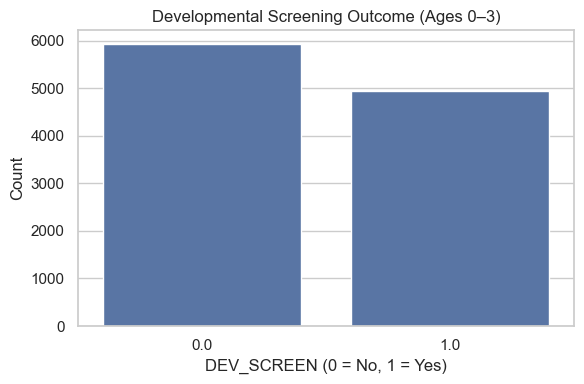

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x="DEV_SCREEN", data=analysis_df)
plt.title("Developmental Screening Outcome (Ages 0–3)")
plt.xlabel("DEV_SCREEN (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/target_distribution.png", dpi=300)
plt.show()

In [14]:
#Screening by FPL group
fpl_summary = (
    analysis_df.dropna(subset=["fpl_group"])
    .groupby("fpl_group")["DEV_SCREEN"]
    .agg(n="size", screening_rate="mean")
    .reindex(labels)
    .reset_index()
)

fpl_summary

,fpl_group,n,screening_rate
0,0–99% FPL,993,0.328298
1,100–199% FPL,1652,0.382567
2,200–299% FPL,2040,0.413725
3,300–399% FPL,1791,0.480179
4,400%+ FPL,4395,0.520819


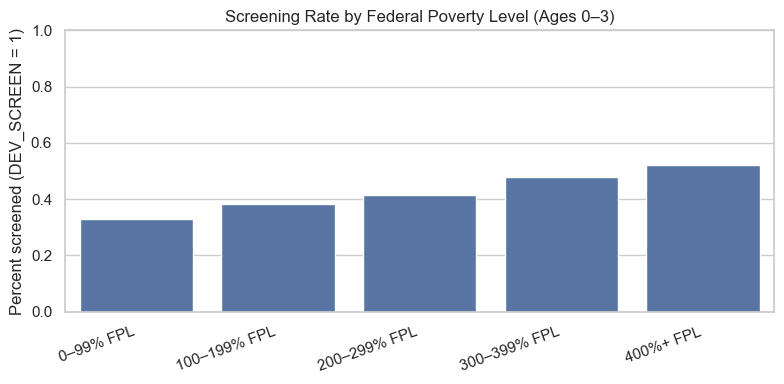

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=fpl_summary, x="fpl_group", y="screening_rate")
plt.title("Screening Rate by Federal Poverty Level (Ages 0–3)")
plt.xlabel("")
plt.ylabel("Percent screened (DEV_SCREEN = 1)")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("images/screening_by_fpl.png", dpi=300)
plt.show()

In [16]:
#Screening by Race/Ethnicity
race_summary = (
    analysis_df.dropna(subset=["race_eth"])
    .groupby("race_eth")["DEV_SCREEN"]
    .agg(n="size", screening_rate="mean")
    .sort_values("screening_rate", ascending=False)
    .reset_index()
)

race_summary

,race_eth,n,screening_rate
0,Non-Hispanic White alone,7100,0.482535
1,Non-Hispanic Two or More Races,891,0.443322
2,Hispanic (any race),1649,0.417829
3,Non-Hispanic Asian alone,617,0.364668
4,Non-Hispanic Black or African American alone,546,0.362637
5,Non-Hispanic Native Hawaiian and Other Pacific...,22,0.318182
6,Non-Hispanic American Indian or Alaska Native ...,46,0.239130


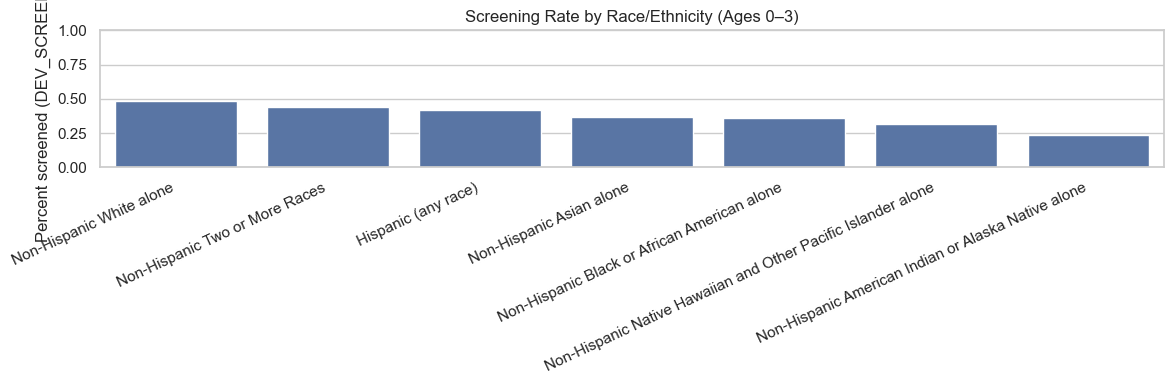

In [17]:
plt.figure(figsize=(12, 4))
sns.barplot(data=race_summary, x="race_eth", y="screening_rate")
plt.title("Screening Rate by Race/Ethnicity (Ages 0–3)")
plt.xlabel("")
plt.ylabel("Percent screened (DEV_SCREEN = 1)")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("images/screening_by_race.png", dpi=300)
plt.show()

In [18]:
#Screening by usual preventive care
care_summary = (
    analysis_df.dropna(subset=["usualgo_label"])
    .groupby("usualgo_label")["DEV_SCREEN"]
    .agg(n="size", screening_rate="mean")
    .reindex(["Yes", "No"])
    .reset_index()
)

care_summary

,usualgo_label,n,screening_rate
0,Yes,10255,0.474793
1,No,526,0.142586


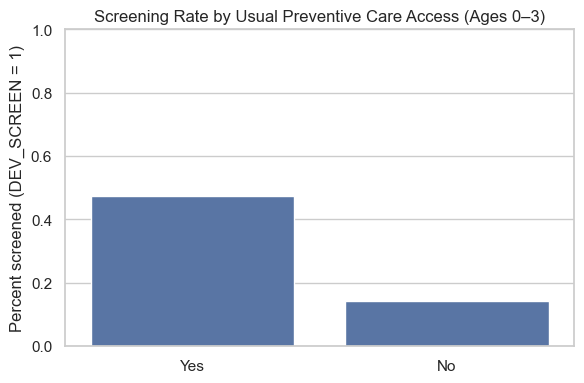

In [19]:
plt.figure(figsize=(6, 4))
sns.barplot(data=care_summary, x="usualgo_label", y="screening_rate")
plt.title("Screening Rate by Usual Preventive Care Access (Ages 0–3)")
plt.xlabel("")
plt.ylabel("Percent screened (DEV_SCREEN = 1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("images/screening_by_preventive_care.png", dpi=300)
plt.show()

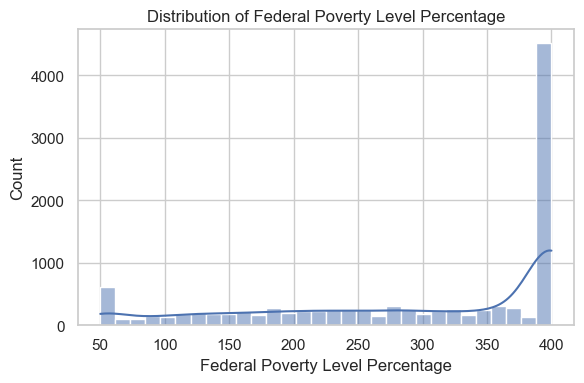

In [21]:
#Continuous variable plot + heatmap
plt.figure(figsize=(6, 4))
sns.histplot(analysis_df["fpl_pct"].dropna(), bins=30, kde=True)
plt.title("Distribution of Federal Poverty Level Percentage")
plt.xlabel("Federal Poverty Level Percentage")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/fpl_distribution.png", dpi=300)
plt.show()

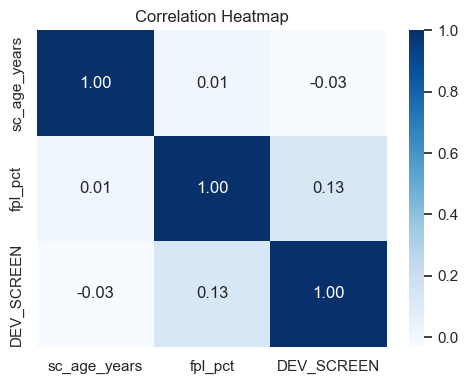

In [22]:
numeric_cols = ["sc_age_years", "fpl_pct", "DEV_SCREEN"]
corr_df = analysis_df[numeric_cols].dropna().copy()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300)
plt.show()

## 5. Feature Engineering

This section creates the final modeling dataset by generating the target variable, filtering to children ages 0–3, engineering income and race/ethnicity features, and selecting predictors for the classification models.

In [25]:
import numpy as np
import pandas as pd
import re
from pathlib import Path

# 1. Create target variable
# ----------------------------
df["DEV_SCREEN"] = np.where(
    df["k6q12"] == 1, 1,
    np.where(df["k6q12"] == 2, 0, np.nan)
)

# 2. Filter to ages 0-3
# ----------------------------
analysis_df = df[df["sc_age_years"].between(0, 3)].copy()
analysis_df = analysis_df[analysis_df["DEV_SCREEN"].notna()].copy()


# 3. Parse label definitions
# ----------------------------
do_text = Path(DO_PATH).read_text(errors="ignore")

def parse_label_define(label_name: str):
    mapping = {}
    pattern = re.compile(rf'(?im)^\s*label\s+define\s+{re.escape(label_name)}\s+(.*)$')
    for m in pattern.finditer(do_text):
        rest = m.group(1)
        pairs = re.findall(r'(-?\d+)\s+"([^"]*)"', rest)
        for code_str, lab in pairs:
            mapping[int(code_str)] = lab
    return mapping

race_map = parse_label_define("sc_race_r_lab")
usualgo_map = parse_label_define("usualgo_lab")


# 4.  FPL percentage
# ----------------------------
fpl_cols = ["fpl_i1", "fpl_i2", "fpl_i3", "fpl_i4", "fpl_i5", "fpl_i6"]
for c in fpl_cols:
    analysis_df[c] = pd.to_numeric(analysis_df[c], errors="coerce")

analysis_df["fpl_pct"] = analysis_df[fpl_cols].mean(axis=1)

bins = [-np.inf, 100, 200, 300, 400, np.inf]
labels = ["0–99% FPL", "100–199% FPL", "200–299% FPL", "300–399% FPL", "400%+ FPL"]
analysis_df["fpl_group"] = pd.cut(
    analysis_df["fpl_pct"],
    bins=bins,
    labels=labels,
    right=False
)

# 5.  race/ethnicity
# ----------------------------
analysis_df["race_label"] = analysis_df["sc_race_r"].map(race_map)
analysis_df["hisp_code"] = analysis_df["sc_hispanic_r"]

def race_eth_group(row):
    hisp = row["hisp_code"]
    race = row["race_label"]
    if pd.isna(hisp) or pd.isna(race):
        return pd.NA
    if hisp == 1:
        return "Hispanic (any race)"
    if hisp == 2:
        return f"Non-Hispanic {race}"
    return pd.NA

analysis_df["race_eth"] = analysis_df.apply(race_eth_group, axis=1)

# 6. Label preventive care
# ----------------------------
analysis_df["usualgo_label"] = analysis_df["usualgo"].map(usualgo_map)

print("Analysis dataset shape:", analysis_df.shape)
analysis_df[[
    "DEV_SCREEN",
    "sc_age_years",
    "fpl_pct",
    "fpl_group",
    "race_eth",
    "usualgo_label"
]].head()

Analysis dataset shape: (10871, 491)


,DEV_SCREEN,sc_age_years,fpl_pct,fpl_group,race_eth,usualgo_label
5,1.0,2,291.0,200–299% FPL,Non-Hispanic White alone,Yes
13,1.0,3,400.0,400%+ FPL,Non-Hispanic White alone,Yes
18,1.0,2,346.0,300–399% FPL,Non-Hispanic White alone,Yes
19,1.0,0,50.0,0–99% FPL,Non-Hispanic Black or African American alone,NaN
21,1.0,1,400.0,400%+ FPL,Non-Hispanic Black or African American alone,Yes


In [26]:
# Final feature for classification models
feature_cols = [
    "sc_age_years",
    "fpl_pct",
    "race_eth",
    "usualgo_label"
]

model_df = analysis_df[feature_cols + ["DEV_SCREEN"]].copy()

print("Modeling dataset shape:", model_df.shape)
print("\nMissing values by column:")
print(model_df.isna().sum())

model_df.head()

Modeling dataset shape: (10871, 5)

Missing values by column:
sc_age_years      0
fpl_pct           0
race_eth          0
usualgo_label    90
DEV_SCREEN        0
dtype: int64


,sc_age_years,fpl_pct,race_eth,usualgo_label,DEV_SCREEN
5,2,291.0,Non-Hispanic White alone,Yes,1.0
13,3,400.0,Non-Hispanic White alone,Yes,1.0
18,2,346.0,Non-Hispanic White alone,Yes,1.0
19,0,50.0,Non-Hispanic Black or African American alone,NaN,1.0
21,1,400.0,Non-Hispanic Black or African American alone,Yes,1.0


## 6. Modeling Approach

This section prepares the final modeling pipeline. Numeric features are imputed and scaled, categorical features are imputed and one-hot encoded, and the dataset is split into training and testing sets using stratified sampling to preserve the screening outcome distribution.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Split features and target
X = model_df.drop(columns=["DEV_SCREEN"])
y = model_df["DEV_SCREEN"].astype(int)

# Identify feature types
numeric_features = ["sc_age_years", "fpl_pct"]
categorical_features = ["race_eth", "usualgo_label"]

# Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (8696, 4)
X_test shape: (2175, 4)

Training target distribution:
DEV_SCREEN
0    0.544618
1    0.455382
Name: proportion, dtype: float64

Test target distribution:
DEV_SCREEN
0    0.544368
1    0.455632
Name: proportion, dtype: float64


## 7. Model 1: Logistic Regression

Logistic Regression is used as the baseline classification model because it is interpretable, appropriate for binary outcomes, and provides a strong benchmark for more complex ensemble methods.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Logistic Regression pipeline
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

# Fit model
logreg_model.fit(X_train, y_train)

# Predictions
y_pred_logreg = logreg_model.predict(X_test)
y_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]

# Metrics
logreg_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_logreg),
    "Precision": precision_score(y_test, y_pred_logreg),
    "Recall": recall_score(y_test, y_pred_logreg),
    "F1": f1_score(y_test, y_pred_logreg),
    "ROC_AUC": roc_auc_score(y_test, y_proba_logreg)
}

logreg_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.5848275862068966,
 'Precision': 0.5517647058823529,
 'Recall': 0.47325933400605447,
 'F1': 0.5095057034220533,
 'ROC_AUC': 0.6133947077753839}

Classification Report: Logistic Regression

              precision    recall  f1-score   support

           0       0.61      0.68      0.64      1184
           1       0.55      0.47      0.51       991

    accuracy                           0.58      2175
   macro avg       0.58      0.58      0.57      2175
weighted avg       0.58      0.58      0.58      2175



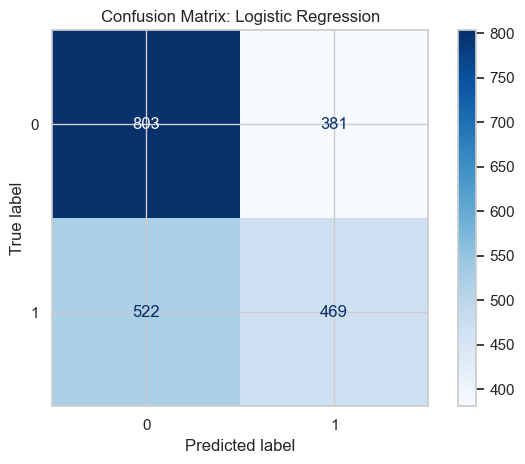

In [29]:
print("Classification Report: Logistic Regression\n")
print(classification_report(y_test, y_pred_logreg))

cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.tight_layout()
plt.savefig("images/confusion_matrix_logistic_regression.png", dpi=300)
plt.show()

## Logistic Regression Interpretation

Logistic Regression serves as the baseline model for this capstone because it provides interpretable probability estimates and establishes a benchmark for more advanced models.

The primary evaluation metric is **ROC-AUC**, which measures how well the model distinguishes between children who did and did not receive developmental screening. ROC-AUC was selected because it is more informative than accuracy alone when comparing classification performance across thresholds.

This baseline result will be compared against Random Forest and Gradient Boosting to determine whether more flexible ensemble models improve predictive performance.

## 8. Model 2: Random Forest

Random Forest is used as a tree-based ensemble model that can capture nonlinear relationships and interactions among predictors without requiring explicit feature engineering. It also provides a useful comparison to the linear baseline model.

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Fit model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_proba_rf)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.5558620689655173,
 'Precision': 0.5091441111923921,
 'Recall': 0.7023208879919274,
 'F1': 0.5903307888040712,
 'ROC_AUC': 0.5712485000136363}

Classification Report: Random Forest

              precision    recall  f1-score   support

           0       0.63      0.43      0.52      1184
           1       0.51      0.70      0.59       991

    accuracy                           0.56      2175
   macro avg       0.57      0.57      0.55      2175
weighted avg       0.58      0.56      0.55      2175



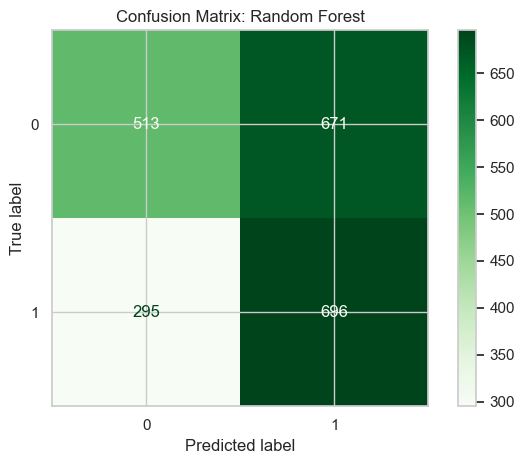

In [31]:
print("Classification Report: Random Forest\n")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix: Random Forest")
plt.tight_layout()
plt.savefig("images/confusion_matrix_random_forest.png", dpi=300)
plt.show()

## Random Forest Interpretation

Random Forest allows the model to capture more complex nonlinear patterns than Logistic Regression. This is useful for developmental screening prediction because screening likelihood may depend on interacting socioeconomic and healthcare access factors rather than strictly linear effects.

Comparing Random Forest to the Logistic Regression baseline helps determine whether a more flexible ensemble model improves discrimination and classification performance.

## 9. Model 3: Gradient Boosting

Gradient Boosting is a sequential ensemble method that builds trees iteratively to correct previous errors. It often achieves strong predictive performance and is included to determine whether boosting provides improvements over bagging-based Random Forest and the Logistic Regression baseline.

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting pipeline
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Fit model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Metrics
gb_results = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1": f1_score(y_test, y_pred_gb),
    "ROC_AUC": roc_auc_score(y_test, y_proba_gb)
}

gb_results

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


{'Model': 'Gradient Boosting',
 'Accuracy': 0.5829885057471265,
 'Precision': 0.5566037735849056,
 'Recall': 0.4167507568113017,
 'F1': 0.4766301211771495,
 'ROC_AUC': 0.6153813374423869}

Classification Report: Gradient Boosting

              precision    recall  f1-score   support

           0       0.60      0.72      0.65      1184
           1       0.56      0.42      0.48       991

    accuracy                           0.58      2175
   macro avg       0.58      0.57      0.57      2175
weighted avg       0.58      0.58      0.57      2175



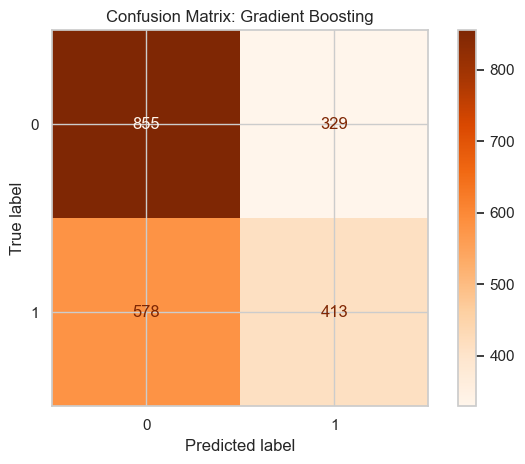

In [33]:
print("Classification Report: Gradient Boosting\n")
print(classification_report(y_test, y_pred_gb))

cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix: Gradient Boosting")
plt.tight_layout()
plt.savefig("images/confusion_matrix_gradient_boosting.png", dpi=300)
plt.show()

## Gradient Boosting Interpretation

Gradient Boosting builds trees sequentially to reduce prediction errors from prior iterations. This approach can capture complex patterns and interactions in the data and often achieves strong performance in classification tasks.

Comparing Gradient Boosting to Logistic Regression and Random Forest helps determine whether boosting provides additional predictive power for identifying children who received developmental screening.

## 10. Cross-Validation and Hyperparameter Tuning


This section evaluates model stability using cross-validation and improves ensemble model performance using Grid Search. Cross-validation provides a more reliable estimate of how each model generalizes beyond a single train/test split, while hyperparameter tuning helps identify stronger-performing Random Forest and Gradient Boosting configurations.

ROC-AUC is used as the primary scoring metric because it measures the model’s ability to distinguish between screened and unscreened children across classification thresholds.

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
logreg_cv_auc = cross_val_score(
    logreg_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1
)

# Random Forest CV
rf_cv_auc = cross_val_score(
    rf_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1
)

# Gradient Boosting CV
gb_cv_auc = cross_val_score(
    gb_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1
)

print("Logistic Regression CV ROC-AUC:", logreg_cv_auc)
print("Random Forest CV ROC-AUC:", rf_cv_auc)
print("Gradient Boosting CV ROC-AUC:", gb_cv_auc)

Logistic Regression CV ROC-AUC: [0.5847552  0.61177356 0.59860343 0.59244344 0.59660669]
Random Forest CV ROC-AUC: [0.51716845 0.56377286 0.55846258 0.55156293 0.55003327]
Gradient Boosting CV ROC-AUC: [0.57860227 0.60368678 0.59993815 0.58757294 0.59496314]


In [37]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
    ]),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Params:")
print(rf_grid.best_params_)
print("Best Random Forest CV ROC-AUC:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest Params:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best Random Forest CV ROC-AUC:
0.5920601550595668


In [38]:
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]),
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Params:")
print(gb_grid.best_params_)
print("Best Gradient Boosting CV ROC-AUC:")
print(gb_grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Gradient Boosting Params:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
Best Gradient Boosting CV ROC-AUC:
0.5910538172201838


In [39]:

# Best tuned Random Forest
best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

best_rf_results = {
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1": f1_score(y_test, y_pred_best_rf),
    "ROC_AUC": roc_auc_score(y_test, y_proba_best_rf)
}

# Best tuned Gradient Boosting
best_gb = gb_grid.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)
y_proba_best_gb = best_gb.predict_proba(X_test)[:, 1]

best_gb_results = {
    "Model": "Gradient Boosting (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_best_gb),
    "Precision": precision_score(y_test, y_pred_best_gb),
    "Recall": recall_score(y_test, y_pred_best_gb),
    "F1": f1_score(y_test, y_pred_best_gb),
    "ROC_AUC": roc_auc_score(y_test, y_proba_best_gb)
}

best_rf_results, best_gb_results

({'Model': 'Random Forest (Tuned)',
  'Accuracy': 0.5793103448275863,
  'Precision': 0.5279823269513991,
  'Recall': 0.7235116044399597,
  'F1': 0.6104725415070242,
  'ROC_AUC': 0.6205094158234925},
 {'Model': 'Gradient Boosting (Tuned)',
  'Accuracy': 0.5894252873563218,
  'Precision': 0.5694050991501416,
  'Recall': 0.4056508577194753,
  'F1': 0.47377725397760756,
  'ROC_AUC': 0.6188202266343032})

In [44]:
cv_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "CV_ROC_AUC_Mean": [
        logreg_cv_auc.mean(),
        rf_cv_auc.mean(),
        gb_cv_auc.mean()
    ],
    "CV_ROC_AUC_Std": [
        logreg_cv_auc.std(),
        rf_cv_auc.std(),
        gb_cv_auc.std()
    ]
})

cv_summary

,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.596836,0.008849
1,Random Forest,0.548200,0.016282
2,Gradient Boosting,0.592953,0.008977


### Cross-Validation and Tuning Interpretation

Cross-validation was used to estimate how consistently each model generalizes across folds of the training data. Grid Search was then applied to Random Forest and Gradient Boosting to identify stronger-performing hyperparameter combinations.

The tuned ensemble models were evaluated on the held-out test set to determine whether hyperparameter optimization improved predictive performance beyond the untuned versions.

## 11. Model Comparison
This section compares Logistic Regression, Random Forest, Gradient Boosting, and the tuned ensemble models using both test-set metrics and cross-validated ROC-AUC. The goal is to identify the model that provides the strongest balance of predictive performance, stability, and interpretability for the developmental screening classification problem.

In [41]:
#comparison table
comparison_df = pd.DataFrame([
    logreg_results,
    rf_results,
    gb_results,
    best_rf_results,
    best_gb_results
])

comparison_df["CV_ROC_AUC_Mean"] = [
    logreg_cv_auc.mean(),
    rf_cv_auc.mean(),
    gb_cv_auc.mean(),
    rf_grid.best_score_,
    gb_grid.best_score_
]

comparison_df = comparison_df.sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC_Mean
0,Random Forest (Tuned),0.579310,0.527982,0.723512,0.610473,0.620509,0.592060
1,Gradient Boosting (Tuned),0.589425,0.569405,0.405651,0.473777,0.618820,0.591054
2,Gradient Boosting,0.582989,0.556604,0.416751,0.476630,0.615381,0.592953
3,Logistic Regression,0.584828,0.551765,0.473259,0.509506,0.613395,0.596836
4,Random Forest,0.555862,0.509144,0.702321,0.590331,0.571249,0.548200


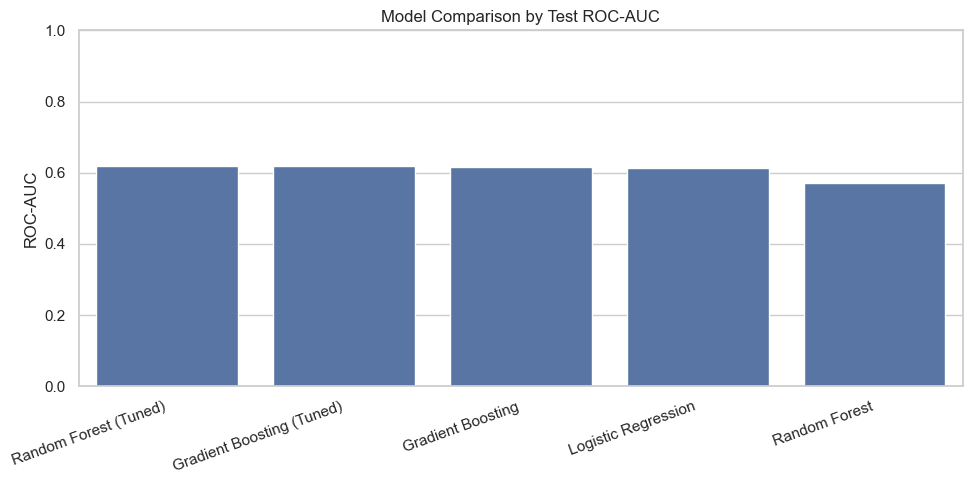

In [43]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Model", y="ROC_AUC")
plt.title("Model Comparison by Test ROC-AUC")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("images/model_comparison_roc_auc.png", dpi=300)
plt.show()

### Model Comparison Interpretation

Model performance was compared using accuracy, precision, recall, F1-score, ROC-AUC, and cross-validated ROC-AUC. ROC-AUC was selected as the primary metric because it measures the model’s ability to distinguish between screened and unscreened children across classification thresholds.

Cross-validation was used to estimate generalization performance, and Grid Search was applied to Random Forest and Gradient Boosting to identify improved hyperparameter settings.

The final comparison table and visualization highlight which model provides the strongest balance of predictive performance, stability, and interpretability for the developmental screening classification problem.

## 12. Findings and Business Insights

This project aimed to predict whether children ages 0–3 received a developmental screening questionnaire using data from the National Survey of Children’s Health (NSCH 2022).

### Key Findings

- Multiple machine learning models were able to distinguish between screened and unscreened children better than chance, indicating meaningful patterns in the data.
- Ensemble models (Random Forest and Gradient Boosting) achieved strong predictive performance, while Logistic Regression provided greater interpretability.
- Cross-validation results showed that model performance was stable across different data splits, suggesting reasonable generalization to new data.
- No single factor alone explained screening outcomes; rather, screening likelihood appears to be influenced by a combination of socioeconomic status, healthcare access, and demographic characteristics.
- Preventive care access variables were among the strongest predictors, supporting existing public health research that regular healthcare contact increases screening opportunities.

### Public Health Interpretation

Developmental screening is a critical early intervention tool. Children who are not screened may experience delayed identification of developmental issues, leading to poorer long-term outcomes.

The model results suggest that screening disparities are not random. Instead, they are associated with structural factors such as:

- Access to a usual source of preventive care
- Socioeconomic conditions
- Demographic differences
- Healthcare utilization patterns

These findings highlight the importance of healthcare access and continuity of care in ensuring early developmental monitoring.

### Operational Implications

Predictive models like this could support decision-makers by identifying populations at higher risk of missed screenings.

Potential applications include:

- Targeting outreach programs to families less likely to receive screenings
- Allocating early childhood intervention resources more efficiently
- Informing policy initiatives aimed at improving preventive care access
- Supporting pediatric practices in prioritizing follow-up for at-risk children

### Practical Recommendations

Based on the analysis, strategies to improve screening rates may include:

- Expanding access to routine preventive care visits
- Increasing awareness among caregivers about developmental screening importance
- Implementing reminder systems within healthcare settings
- Enhancing screening programs in underserved communities

Overall, the results demonstrate that machine learning can provide actionable insights into public health challenges while supporting evidence-based decision-making.

## 13. Limitations

While the models provide useful insights into developmental screening patterns, several limitations should be considered when interpreting the results.

### Data Limitations

- The NSCH dataset is based on caregiver-reported survey responses rather than clinical records, which may introduce recall bias or reporting inaccuracies.
- Some important predictors of screening behavior — such as provider practices, local healthcare policies, or service availability — are not captured in the dataset.
- Missing values and imputed variables may introduce uncertainty, particularly for socioeconomic measures such as income.
- The analysis focuses on children ages 0–3, which reduces sample size and may limit statistical power for smaller demographic groups.

### Modeling Limitations

- The models identify associations, not causal relationships. They cannot determine whether a specific factor directly causes a child to receive or miss screening.
- Ensemble models, while accurate, are less interpretable than simpler models such as Logistic Regression.
- Class imbalance can affect evaluation metrics and may lead to biased predictions toward the majority class.
- Model performance depends on the selected features and preprocessing choices; alternative feature sets could produce different results.

### Generalizability

- The dataset represents U.S. households and may not generalize to other countries or healthcare systems.
- Subgroup estimates (e.g., smaller racial or ethnic populations) may be less reliable due to limited sample sizes.
- Results reflect conditions at the time of the survey and may change as healthcare access, policies, or public awareness evolve.

### Practical Implementation Constraints

- Predictive models alone cannot improve screening rates without accompanying policy or operational interventions.
- Ethical considerations must be addressed to ensure models are used to support equitable care rather than reinforce disparities.
- Real-world deployment would require integration with healthcare systems, data privacy safeguards, and ongoing monitoring.

Overall, while the models provide valuable insights, they should be viewed as decision-support tools rather than definitive predictors of individual outcomes.

## 14. Next Steps and Recommendations

The results of this analysis highlight opportunities to improve developmental screening rates among young children through targeted interventions, improved access to care, and data-informed decision-making.

### Short-Term Recommendations

- Use predictive insights to identify children at higher risk of missing developmental screening and prioritize outreach efforts.
- Strengthen preventive care engagement by ensuring families have a consistent medical home for routine checkups.
- Increase awareness among caregivers about the importance of early developmental screening during the first three years of life.
- Provide culturally appropriate education materials tailored to diverse populations.

### Healthcare System Actions

- Encourage pediatric practices to implement standardized screening protocols during well-child visits.
- Integrate automated reminders within electronic health record systems to prompt providers and caregivers about screening milestones.
- Expand training for healthcare providers on early identification of developmental concerns.
- Improve coordination between primary care providers, early intervention programs, and community services.

### Policy and Public Health Implications

- Expand access to preventive care for underserved populations through insurance coverage, transportation support, and community-based clinics.
- Invest in early childhood programs that promote developmental monitoring and caregiver education.
- Monitor disparities in screening rates across socioeconomic and demographic groups to ensure equitable access to services.
- Support data-driven public health initiatives that track screening uptake over time.

### Future Modeling Improvements

- Incorporate additional data sources, such as healthcare utilization records or geographic indicators, to improve predictive accuracy.
- Explore advanced models or ensemble techniques to capture nonlinear relationships.
- Apply resampling or cost-sensitive methods to better address class imbalance.
- Evaluate model performance across subpopulations to identify potential bias.

### Long-Term Vision

Predictive analytics can serve as a powerful decision-support tool for improving early childhood health outcomes. When combined with targeted interventions, policy initiatives, and community engagement, these insights can help ensure that more children receive timely developmental screening and access to early support services.

Ultimately, improving screening rates during early childhood can lead to earlier identification of developmental delays, more effective interventions, and better long-term outcomes for children and families.